In [985]:
# Import torch
import torch
from scipy.optimize import optimize

# Setup device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"

# Setup random seed
RANDOM_SEED = 42

In [986]:
# Create a dataset with Scikit-Learn's make_moons()
from sklearn.datasets import make_moons
X_data, Y_data = make_moons(n_samples=1000, shuffle=True, noise=0.07, random_state=42)
X_data[:10], Y_data[:10]

(array([[-0.03341062,  0.4213911 ],
        [ 0.99882703, -0.4428903 ],
        [ 0.88959204, -0.32784256],
        [ 0.34195829, -0.41768975],
        [-0.83853099,  0.53237483],
        [ 0.59906425, -0.28977331],
        [ 0.29009023, -0.2046885 ],
        [-0.03826868,  0.45942924],
        [ 1.61377123, -0.2939697 ],
        [ 0.693337  ,  0.82781911]]),
 array([1, 1, 1, 1, 0, 1, 1, 1, 1, 0]))

In [987]:
# Turn data into a DataFrame
import pandas as pd
moons = pd.DataFrame({"X0": X_data[:, 0], "X1": X_data[:, 1], "label": Y_data})
moons.head()

,X0,X1,label
0,-0.033411,0.421391,1
1,0.998827,-0.442890,1
2,0.889592,-0.327843,1
3,0.341958,-0.417690,1
4,-0.838531,0.532375,0


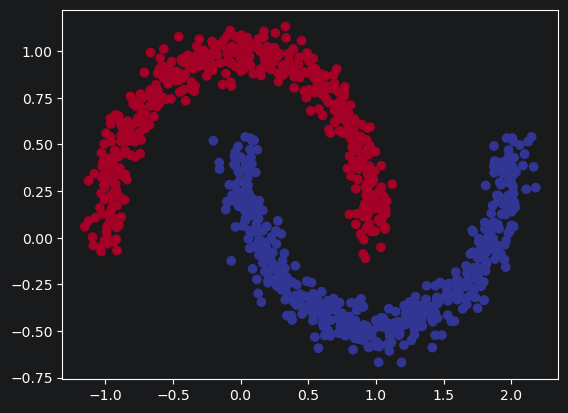

In [988]:
# Visualize the data on a scatter plot
import matplotlib.pyplot as plt
plt.scatter(moons["X0"], moons["X1"], c=moons["label"], cmap=plt.cm.RdYlBu)

In [989]:
# Turn data into tensors of dtype float
X = torch.tensor(X_data, dtype=torch.float)
Y = torch.tensor(Y_data, dtype=torch.float) # labels need to be of type long
# Split the data into train and test sets (80% train, 20% test)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test  = train_test_split(X, Y, test_size=0.2, random_state=RANDOM_SEED)
len(X_train), len(X_test), len(y_train), len(y_test)

(800, 200, 800, 200)

In [990]:
import torch
from torch import nn

# Inherit from nn.Module to make a model capable of fitting the mooon data
class MoonModelV0(nn.Module):
    ## Your code here ##
    def __init__(self, in_features=2, hidden_units=20, out_features=1):
        super().__init__()
        self.layer1 = nn.Linear(in_features=in_features, out_features=hidden_units)
        self.layer2 = nn.Linear(in_features=hidden_units, out_features=hidden_units)
        self.layer3 = nn.Linear(in_features=hidden_units, out_features=out_features)
        self.relu = nn.ReLU()

    def forward(self, x):
        ## Your code here ##
        return self.layer3(self.relu(self.layer2(self.relu(self.layer1(x)))))

# Instantiate the model
## Your code here ##
moon_model = MoonModelV0(2, 200, 1).to(device)
moon_model

MoonModelV0(
  (layer1): Linear(in_features=2, out_features=200, bias=True)
  (layer2): Linear(in_features=200, out_features=200, bias=True)
  (layer3): Linear(in_features=200, out_features=1, bias=True)
  (relu): ReLU()
)

In [991]:
# Setup loss function
loss_fn = nn.BCEWithLogitsLoss() # BCE = Binary Cross Entropy, with logits = raw outputs of model
# Setup optimizer to optimize model's parameters
optimizer = torch.optim.SGD(params=moon_model.parameters(), lr=0.05)

In [992]:
# What's coming out of our model?

# logits (raw outputs of model)
print("Logits:")
## Your code here ##
logits_train = (moon_model(X_train.to(device))[:10]).squeeze()
print(logits_train)
# Prediction probabilities
print("Pred probs:")
## Your code here ##
preds_train = torch.sigmoid(logits_train)
print(preds_train)
# Prediction labels
print("Pred labels:")
## Your code here ##
pred_labels_train = torch.round(preds_train)# round to 0 or 1
print(pred_labels_train)

Logits:
tensor([-0.5083, -0.0603, -0.2141, -0.2087, -0.0876, -0.1891, -0.1212, -0.0733,
        -0.2668, -0.0452], device='cuda:0', grad_fn=<SqueezeBackward0>)
Pred probs:
tensor([0.3756, 0.4849, 0.4467, 0.4480, 0.4781, 0.4529, 0.4697, 0.4817, 0.4337,
        0.4887], device='cuda:0', grad_fn=<SigmoidBackward0>)
Pred labels:
tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0.], device='cuda:0',
       grad_fn=<RoundBackward0>)


In [993]:
# Let's calculate the accuracy using accuracy from TorchMetrics
# !pip -q install torchmetrics # Colab doesn't come with torchmetrics
from torchmetrics import Accuracy

## TODO: Uncomment this code to use the Accuracy function
acc_fn = Accuracy(task="multiclass", num_classes=2).to(device) # send accuracy function to device
acc_fn

MulticlassAccuracy()

In [994]:
## TODO: Uncomment this to set the seed
torch.manual_seed(RANDOM_SEED)

# Setup epochs
epochs = 1000

# Send data to the device
X_train = X_train.to(device)
X_test = X_test.to(device)
y_train = y_train.to(device)
y_test = y_test.to(device)

# Loop through the data
for epoch in range(epochs):
  # Training
  moon_model.train()

  # 1. Forward pass (logits output)
  y_logits = moon_model(X_train).squeeze()
  # Turn logits into prediction probabilities
  y_probs = torch.sigmoid(y_logits)

  # Turn prediction probabilities into prediction labels
  y_preds = torch.round(y_probs) # round to 0 or 1

  # 2. Calculaute the loss
  loss = loss_fn(y_logits, y_train) # loss = compare model raw outputs to desired model outputs

  # Calculate the accuracy
  acc = acc_fn(y_preds, y_train.int()) # the accuracy function needs to compare pred labels (not logits) with actual labels

  # 3. Zero the gradients
  optimizer.zero_grad()

  # 4. Loss backward (perform backpropagation) - https://brilliant.org/wiki/backpropagation/#:~:text=Backpropagation%2C%20short%20for%20%22backward%20propagation,to%20the%20neural%20network's%20weights.
  loss.backward()

  # 5. Step the optimizer (gradient descent) - https://towardsdatascience.com/gradient-descent-algorithm-a-deep-dive-cf04e8115f21#:~:text=Gradient%20descent%20(GD)%20is%20an,e.g.%20in%20a%20linear%20regression) 
  optimizer.step()

  ### Testing
  moon_model.eval()
  with torch.inference_mode():
    # 1. Forward pass (to get the logits)
    test_logits = moon_model(X_test).squeeze()
    # Turn the test logits into prediction labels
    test_probs = torch.sigmoid(test_logits)
    test_labels = torch.round(test_probs)

    # 2. Calculate the test loss/acc
    test_loss = loss_fn(test_logits, y_test)
    test_acc = acc_fn(test_labels, y_test.int())

  # Print out what's happening every 100 epochs
  if epoch % 100 == 0:
        print(f"Epoch: {epoch} | Loss: {loss:.2f} Acc: {acc:.2f} | Test loss: {test_loss:.2f} Test acc: {test_acc:.2f}")

Epoch: 0 | Loss: 0.72 Acc: 0.50 | Test loss: 0.69 Test acc: 0.50
Epoch: 100 | Loss: 0.24 Acc: 0.89 | Test loss: 0.24 Test acc: 0.90
Epoch: 200 | Loss: 0.19 Acc: 0.92 | Test loss: 0.18 Test acc: 0.93
Epoch: 300 | Loss: 0.15 Acc: 0.94 | Test loss: 0.14 Test acc: 0.94
Epoch: 400 | Loss: 0.11 Acc: 0.95 | Test loss: 0.10 Test acc: 0.97
Epoch: 500 | Loss: 0.08 Acc: 0.98 | Test loss: 0.07 Test acc: 0.99
Epoch: 600 | Loss: 0.06 Acc: 0.99 | Test loss: 0.05 Test acc: 0.99
Epoch: 700 | Loss: 0.04 Acc: 0.99 | Test loss: 0.04 Test acc: 1.00
Epoch: 800 | Loss: 0.03 Acc: 1.00 | Test loss: 0.03 Test acc: 1.00
Epoch: 900 | Loss: 0.03 Acc: 1.00 | Test loss: 0.02 Test acc: 1.00


In [995]:
# Plot the model predictions
import numpy as np

def plot_decision_boundary(model, X, y):
  
    # Put everything to CPU (works better with NumPy + Matplotlib)
    model.to("cpu")
    X, y = X.to("cpu"), y.to("cpu")

    # Source - https://madewithml.com/courses/foundations/neural-networks/ 
    # (with modifications)
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 101), 
                         np.linspace(y_min, y_max, 101))

    # Make features
    X_to_pred_on = torch.from_numpy(np.column_stack((xx.ravel(), yy.ravel()))).float()

    # Make predictions
    model.eval()
    with torch.inference_mode():
        y_logits = model(X_to_pred_on)

    # Test for multi-class or binary and adjust logits to prediction labels
    if len(torch.unique(y)) > 2:
        y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1) # mutli-class
    else: 
        y_pred = torch.round(torch.sigmoid(y_logits)) # binary
    
    # Reshape preds and plot
    y_pred = y_pred.reshape(xx.shape).detach().numpy()
    plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha=0.7)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())

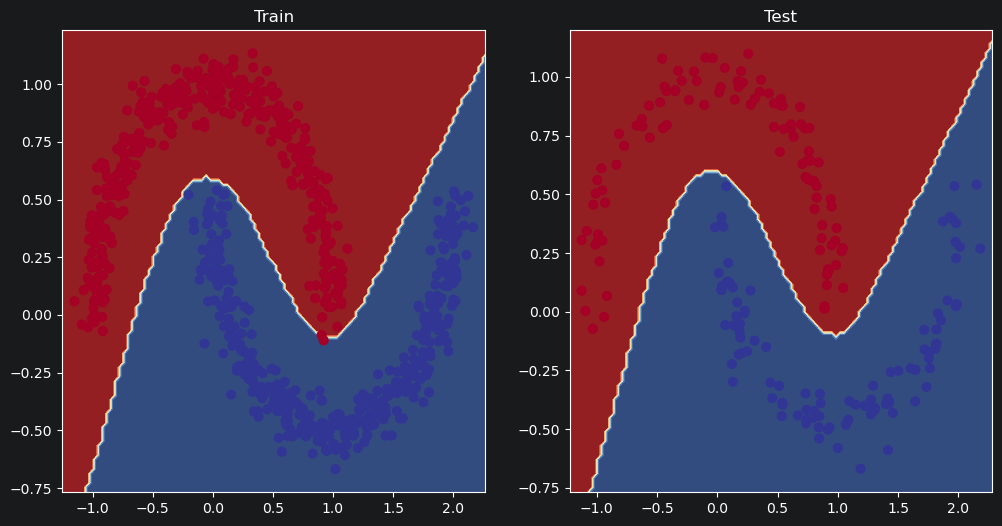

In [996]:
# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(moon_model, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(moon_model, X_test, y_test)


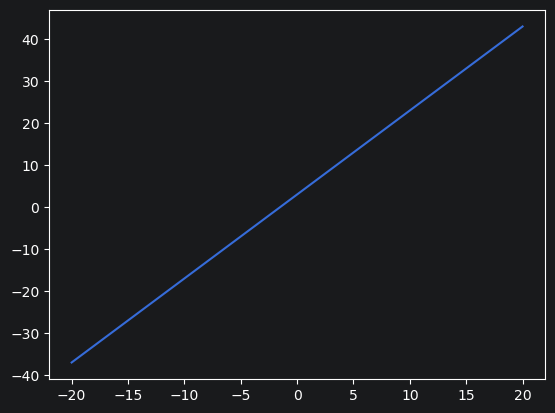

In [997]:
# Create a straight line tensor
line_data = [[x, 2*x + 3] for x in range(-20, 21)]
straight_line = torch.tensor(line_data, dtype=torch.float)
plt.plot(straight_line[:, 0], straight_line[:, 1])

Text(0.5, 1.0, 'X/Y')

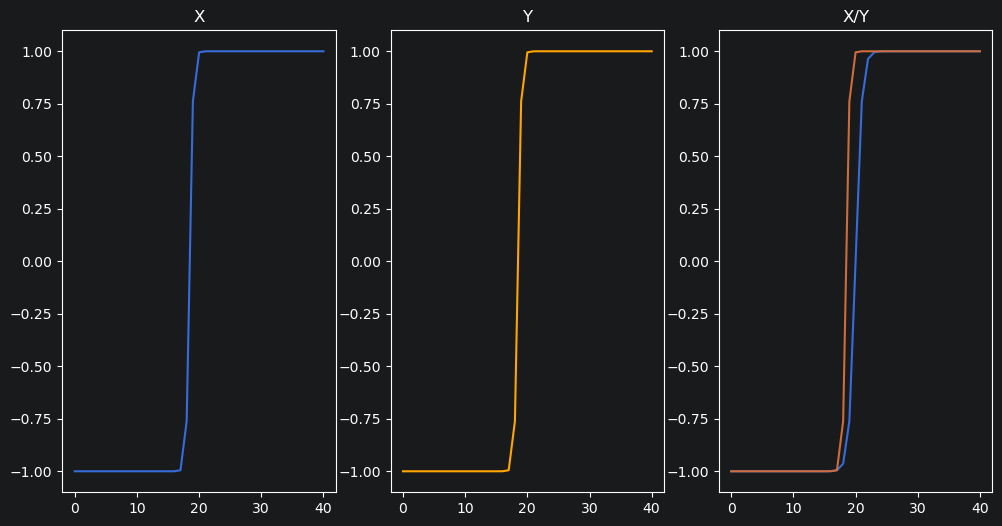

In [998]:
# Test torch.tanh() on the tensor and plot it
plt.figure(figsize=(12, 6))
plt.subplot(1, 3, 1)
plt.plot(torch.tanh(straight_line[:, 1]))
plt.title("X")

plt.subplot(1, 3, 2)
plt.plot(torch.tanh(straight_line[:, 1]), color="orange")
plt.title("Y")

plt.subplot(1, 3, 3)
plt.plot(torch.tanh(straight_line))
plt.title("X/Y")


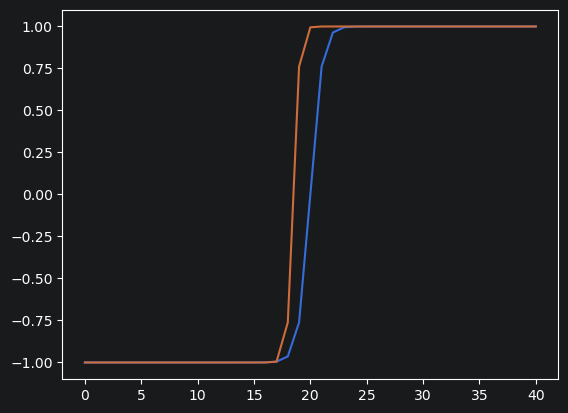

In [999]:
# Replicate torch.tanh() and plot it
def tanh(x):
    return (torch.exp(x) - torch.exp(-x)) / (torch.exp(x) + torch.exp(-x))

plt.plot(tanh(straight_line))


## 7. Create a multi-class dataset using the [spirals data creation function from CS231n](https://cs231n.github.io/neural-networks-case-study/) (see below for the code).
  * Split the data into training and test sets (80% train, 20% test) as well as turn it into PyTorch tensors.
  * Construct a model capable of fitting the data (you may need a combination of linear and non-linear layers).
  * Build a loss function and optimizer capable of handling multi-class data (optional extension: use the Adam optimizer instead of SGD, you may have to experiment with different values of the learning rate to get it working).
  * Make a training and testing loop for the multi-class data and train a model on it to reach over 95% testing accuracy (you can use any accuracy measuring function here that you like) - 1000 epochs should be plenty.
  * Plot the decision boundaries on the spirals dataset from your model predictions, the `plot_decision_boundary()` function should work for this dataset too.

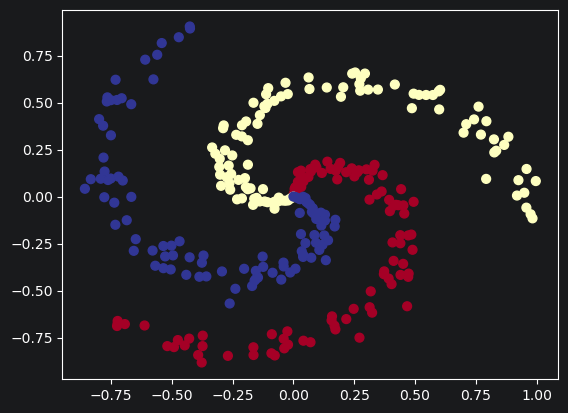

In [1000]:
# Code for creating a spiral dataset from CS231n
import numpy as np
import matplotlib.pyplot as plt
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
N = 100 # number of points per class
D = 2 # dimensionality
K = 3 # number of classes
X = np.zeros((N*K,D)) # data matrix (each row = single example)
y = np.zeros(N*K, dtype='uint8') # class labels
for j in range(K):
  ix = range(N*j,N*(j+1))
  r = np.linspace(0.0,1,N) # radius
  t = np.linspace(j*4,(j+1)*4,N) + np.random.randn(N)*0.2 # theta
  X[ix] = np.c_[r*np.sin(t), r*np.cos(t)]
  y[ix] = j
# lets visualize the data
plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
plt.show()

In [1001]:
# Turn data into tensors
import torch
from sklearn.model_selection import train_test_split

X = torch.from_numpy(X).type(torch.float) # features as float32
y = torch.from_numpy(y).type(torch.LongTensor) # labels need to be of type long

# Create train and test splits
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED)
X_train[:10], y_train[:10]

(tensor([[ 0.0396, -0.3208],
         [ 0.3179, -0.5041],
         [ 0.0321,  0.0514],
         [ 0.8259,  0.2347],
         [ 0.4942,  0.5472],
         [ 0.2689,  0.1397],
         [ 0.1744,  0.1377],
         [-0.5018, -0.2610],
         [ 0.4898, -0.2830],
         [ 0.8337,  0.2439]]),
 tensor([2, 0, 0, 1, 1, 0, 0, 2, 0, 1]))

In [1002]:
# Let's calculate the accuracy for when we fit our model
# !pip -q install torchmetrics # colab doesn't come with torchmetrics
from torchmetrics import Accuracy

## TODO: uncomment the two lines below to send the accuracy function to the device
acc_fn = Accuracy(task="multiclass", num_classes=3).to(device)
acc_fn

MulticlassAccuracy()

In [1003]:
# Prepare device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"

# Create model by subclassing nn.Module
class SpiralModelV0(nn.Module):
    def __init__(self, in_features=2, hidden_units=20, out_features=1):
        super().__init__()
        self.layer1 = nn.Linear(in_features=in_features, out_features=hidden_units)
        self.layer2 = nn.Linear(in_features=hidden_units, out_features=hidden_units)
        self.layer3 = nn.Linear(in_features=hidden_units, out_features=hidden_units)
        self.layer4 = nn.Linear(in_features=hidden_units, out_features=out_features)
        self.tanh =  nn.Tanh()

    def forward(self, x):
        return self.layer4(self.tanh(self.layer3(self.tanh(self.layer2(self.tanh(self.layer1(x)))))))
# Instantiate model and send it to device
spiralModel = SpiralModelV0(2, 256, 3).to(device)
spiralModel

SpiralModelV0(
  (layer1): Linear(in_features=2, out_features=256, bias=True)
  (layer2): Linear(in_features=256, out_features=256, bias=True)
  (layer3): Linear(in_features=256, out_features=256, bias=True)
  (layer4): Linear(in_features=256, out_features=3, bias=True)
  (tanh): Tanh()
)

In [1004]:
# Setup data to be device agnostic
device = "cuda" if torch.cuda.is_available() else "cpu"

# Print out first 10 untrained model outputs (forward pass)
print("Logits:")
## Your code here ##
y_logits = spiralModel(X_train.to(device))[:10].squeeze()
print(y_logits)

print("Pred probs:")
## Your code here ##
y_probs = torch.softmax(y_logits, dim=1)
print(y_probs)

print("Pred labels:")
## Your code here ##
y_labels = torch.argmax(y_probs, dim=1)
print(y_labels)

y_logits, y_probs, y_labels


Logits:
tensor([[0.1229, 0.0619, 0.2664],
        [0.1473, 0.0570, 0.2616],
        [0.0944, 0.0503, 0.2351],
        [0.1167, 0.0018, 0.1502],
        [0.0785, 0.0101, 0.1462],
        [0.1008, 0.0377, 0.2119],
        [0.0958, 0.0419, 0.2183],
        [0.0851, 0.0671, 0.2693],
        [0.1404, 0.0419, 0.2341],
        [0.1163, 0.0010, 0.1484]], device='cuda:0', grad_fn=<SqueezeBackward0>)
Pred probs:
tensor([[0.3231, 0.3040, 0.3730],
        [0.3295, 0.3011, 0.3694],
        [0.3218, 0.3079, 0.3704],
        [0.3418, 0.3047, 0.3535],
        [0.3329, 0.3109, 0.3562],
        [0.3272, 0.3072, 0.3656],
        [0.3249, 0.3079, 0.3672],
        [0.3140, 0.3084, 0.3776],
        [0.3328, 0.3016, 0.3655],
        [0.3420, 0.3048, 0.3532]], device='cuda:0', grad_fn=<SoftmaxBackward0>)
Pred labels:
tensor([2, 2, 2, 2, 2, 2, 2, 2, 2, 2], device='cuda:0')


(tensor([[0.1229, 0.0619, 0.2664],
         [0.1473, 0.0570, 0.2616],
         [0.0944, 0.0503, 0.2351],
         [0.1167, 0.0018, 0.1502],
         [0.0785, 0.0101, 0.1462],
         [0.1008, 0.0377, 0.2119],
         [0.0958, 0.0419, 0.2183],
         [0.0851, 0.0671, 0.2693],
         [0.1404, 0.0419, 0.2341],
         [0.1163, 0.0010, 0.1484]], device='cuda:0', grad_fn=<SqueezeBackward0>),
 tensor([[0.3231, 0.3040, 0.3730],
         [0.3295, 0.3011, 0.3694],
         [0.3218, 0.3079, 0.3704],
         [0.3418, 0.3047, 0.3535],
         [0.3329, 0.3109, 0.3562],
         [0.3272, 0.3072, 0.3656],
         [0.3249, 0.3079, 0.3672],
         [0.3140, 0.3084, 0.3776],
         [0.3328, 0.3016, 0.3655],
         [0.3420, 0.3048, 0.3532]], device='cuda:0', grad_fn=<SoftmaxBackward0>),
 tensor([2, 2, 2, 2, 2, 2, 2, 2, 2, 2], device='cuda:0'))

In [1005]:
# Setup loss function and optimizer
loss_fn = nn.CrossEntropyLoss() # CrossEntropyLoss = for multi-class classification problems
optimizer = torch.optim.Adam(spiralModel.parameters(), lr=0.005) # SGD = Stochastic Gradient Descent

In [1006]:
# Build a training loop for the model
torch.manual_seed(RANDOM_SEED)

# Setup epochs
epochs = 10000

# Send data to the device
X_train = X_train.to(device)
X_test = X_test.to(device)
y_train = y_train.to(device)
y_test = y_test.to(device)
# Loop over data
for epoch in range(epochs):
  ## Training
  spiralModel.train()
  # 1. Forward pass
  y_logits = spiralModel(X_train)
  y_preds = torch.softmax(y_logits, dim=1)
  y_labels = torch.argmax(y_preds, dim=1)

  # 2. Calculate the loss
  loss = loss_fn(y_logits, y_train)
  acc = acc_fn(y_preds, y_train)
  # 3. Optimizer zero grad
  optimizer.zero_grad()

  # 4. Loss backward
  loss.backward()

  # 5. Optimizer step
  optimizer.step()

  ## Testing
  spiralModel.eval()
  with torch.inference_mode():
    # 1. Forward pass
    test_logits = spiralModel(X_test).squeeze()
    # 2. Calculate loss and acc
    test_loss = loss_fn(test_logits, y_test)
    test_preds = torch.softmax(test_logits, dim=1)
    test_acc = acc_fn(test_preds, y_test)

  # Print out what's happening every 100 epochs
  if epoch % 100 == 0:
    print(f"Epoch: {epoch} | Loss: {loss:.2f} Acc: {acc:.2f} | Test loss: {test_loss:.2f} Test acc: {test_acc:.2f}")
  if test_acc > 0.9999:
    print(f"Stopping early at epoch {epoch} with acc: {acc:.2f} and test_acc: {test_acc:.2f}")
    break


Epoch: 0 | Loss: 1.09 Acc: 0.32 | Test loss: 1.04 Test acc: 0.48
Stopping early at epoch 39 with acc: 0.97 and test_acc: 1.00


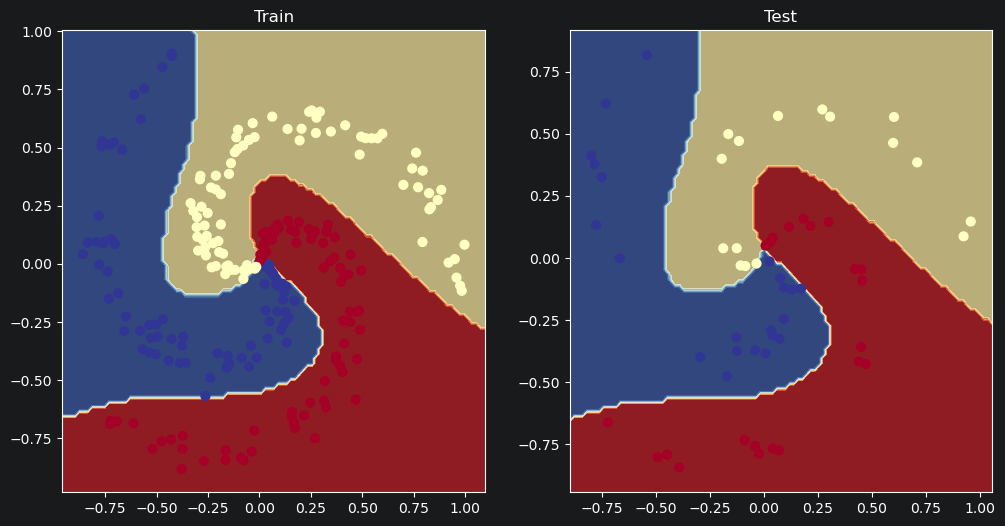

In [1007]:
# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(spiralModel, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(spiralModel, X_test, y_test)